# 07 — Plotting Gallery

`iwfm_io.plots` has **58 functions across 13 modules**, all built on
matplotlib. This notebook is a curated tour — one or two representative
figures per module, all DLL-free through the `open_model()` adapter.

Conventions shared by every function:

- first argument is a model (an `IOModelAdapter` **or** a DLL
  `IWFMModel` — anything with the `nodes_df()`/`elements_df()` interface)
- returns `(fig, ax)` (map primitives also return the contour set /
  colorbar)
- accepts `save_path=` to write a PNG directly

**Requires:** the sample model with Results. A handful of budget
convenience wrappers (`plot_budget_timeseries`, `plot_budget_sankey`,
…) query budgets through the DLL model interface — for those we show the
generic data-first variants, which work anywhere.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt


def find_sample_model():
    env = os.environ.get("IWFM_SAMPLE_MODEL")
    if env:
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / ".assets" / "sample_model"
        if cand.is_dir():
            return cand
    raise FileNotFoundError("sample model not found — see notebook 01")


SAMPLE_MODEL = find_sample_model()
RESULTS_DIR = SAMPLE_MODEL / "Results"
BEGIN, END = "10/01/1990_24:00", "09/30/2000_24:00"

from iwfm_io import open_model

model = open_model(SAMPLE_MODEL)
print(f"{model.n_nodes} nodes / {model.n_elements} elements / "
      f"{model.n_layers} layers")

441 nodes / 400 elements / 2 layers


## Maps

Grid, terrain, streams, layer geometry, wells, and head fields.

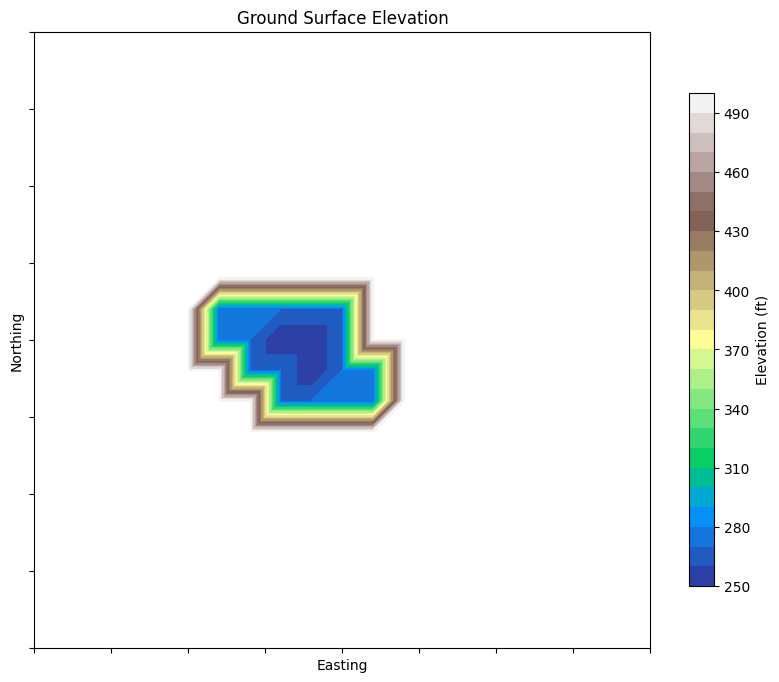

In [2]:
from iwfm_io.plots import maps

fig, ax = maps.plot_ground_surface_elevation(model)
plt.show()

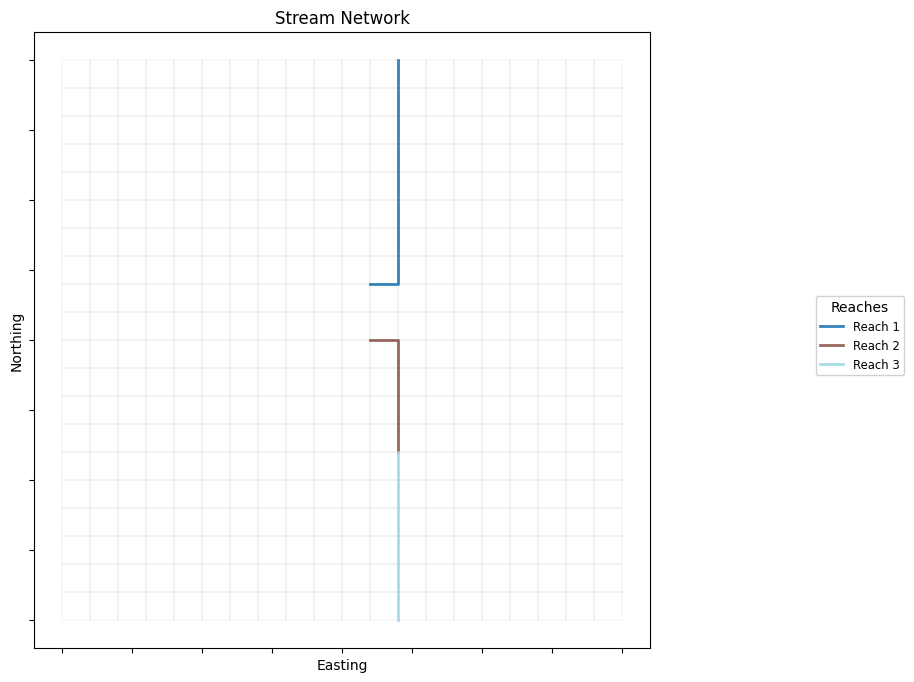

In [3]:
fig, ax = maps.plot_stream_network(model)
plt.show()

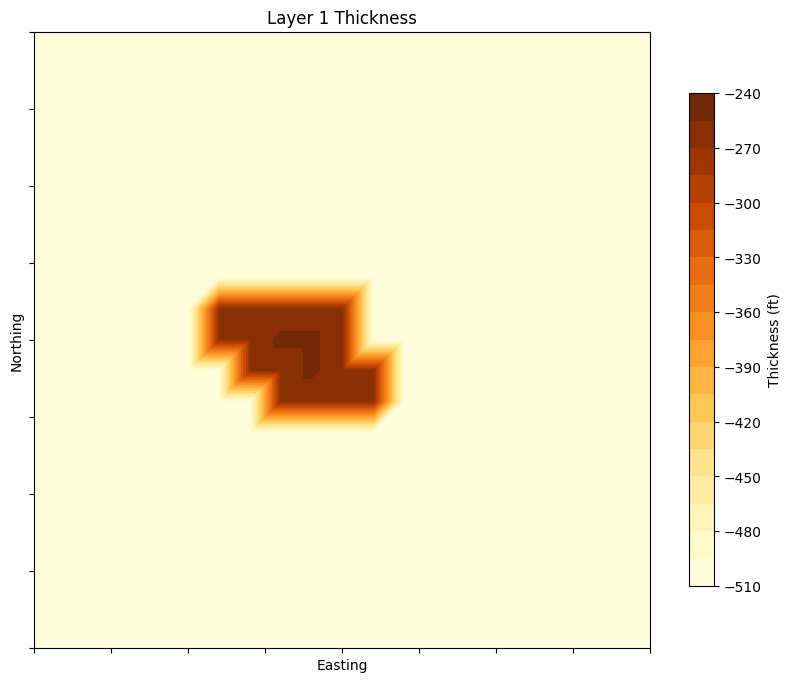

In [4]:
fig, ax = maps.plot_layer_thickness(model, layer=1)
plt.show()

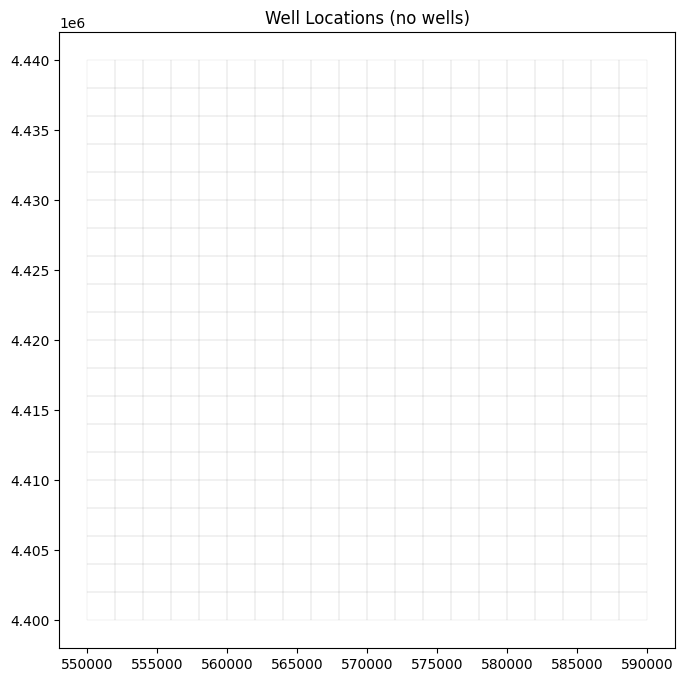

In [5]:
fig, ax = maps.plot_well_locations(model)
plt.show()

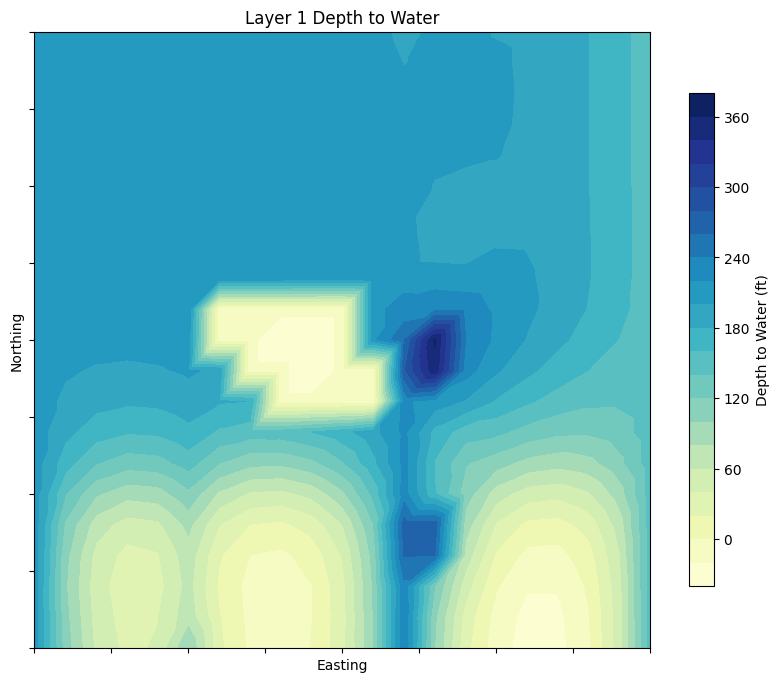

In [6]:
fig, ax = maps.plot_depth_to_water(model, layer=1)
plt.show()

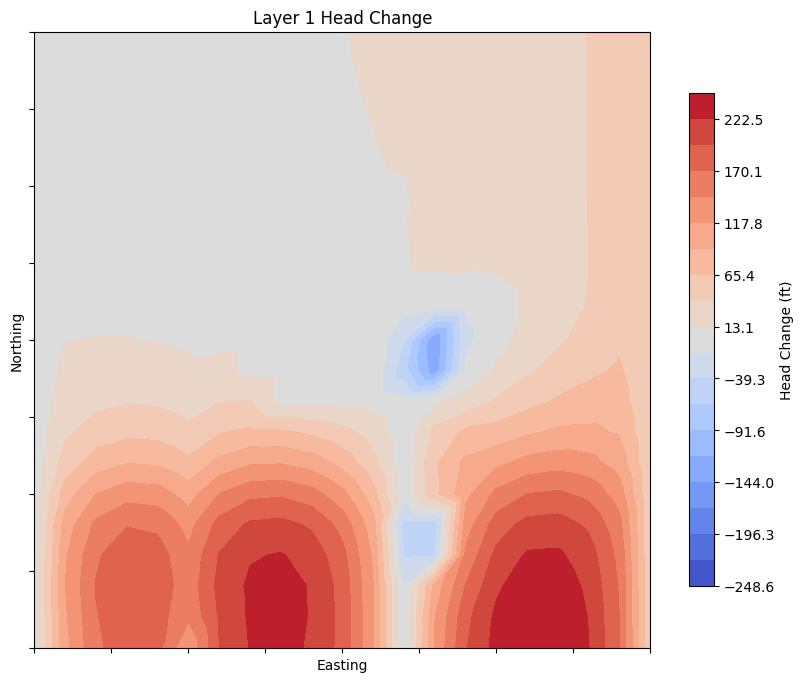

In [7]:
# Head change between the first and last timestep
heads = model.heads_df(layer=1)
fig, ax = maps.plot_head_change(
    model, layer=1,
    heads_t1=heads.iloc[0].values, heads_t2=heads.iloc[-1].values)
plt.show()

## Profiles

Vertical slices: a stratigraphic cross-section along any transect, and
the stream longitudinal profile.

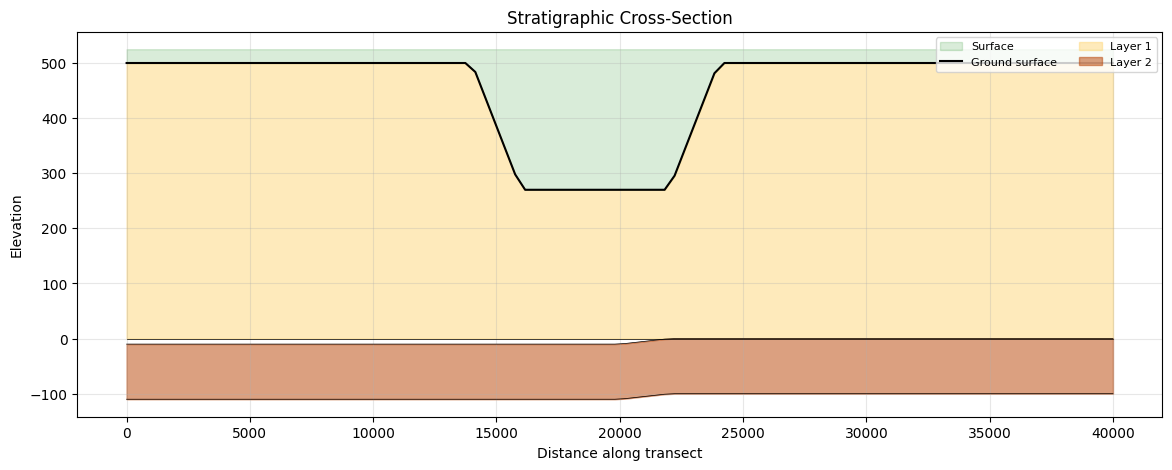

In [8]:
from iwfm_io.plots import profiles

nodes = model.nodes_df()
x_mid = nodes["x"].median()
transect = [(x_mid, nodes["y"].min()), (x_mid, nodes["y"].max())]

fig, ax = profiles.plot_stratigraphic_cross_section(
    model, points=transect, show_heads=False)
plt.show()

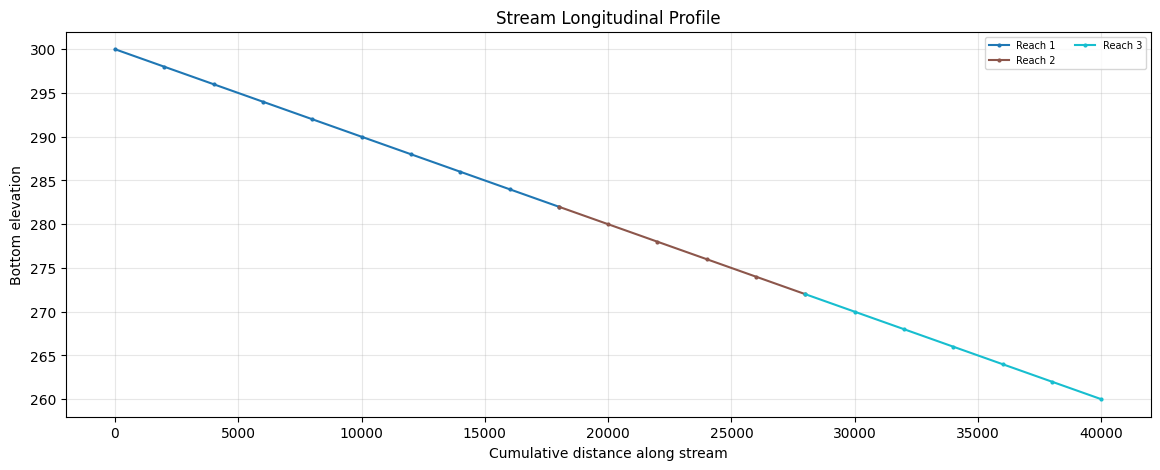

In [9]:
fig, ax = profiles.plot_stream_longitudinal_profile(model)
plt.show()

## Time series

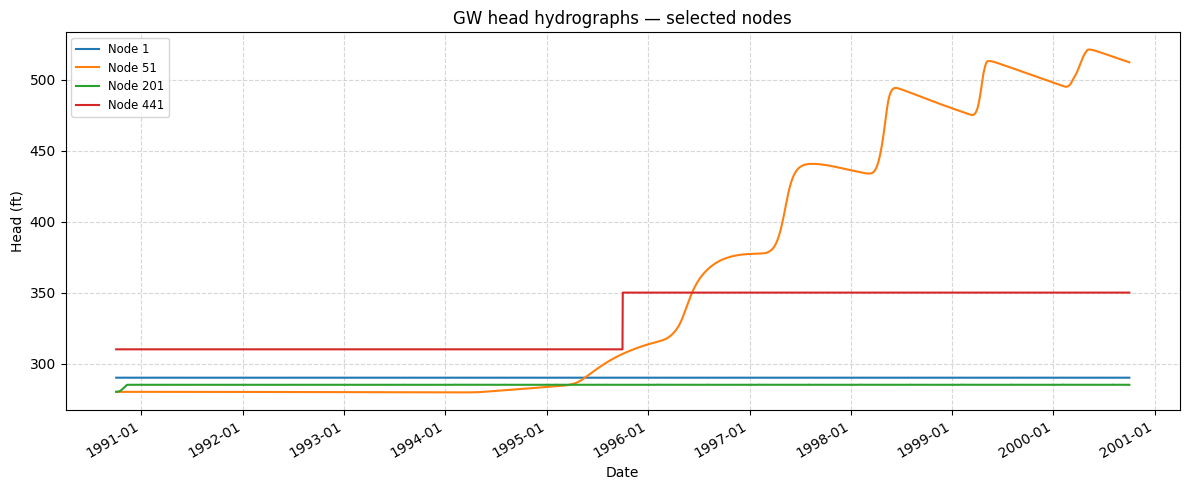

In [10]:
from iwfm_io.plots import timeseries

fig, ax = timeseries.plot_gw_head_hydrographs(
    model, node_indices=[0, 50, 200, 440], layer=1,
    begin_date=BEGIN, end_date=END,
    title="GW head hydrographs — selected nodes")
plt.show()

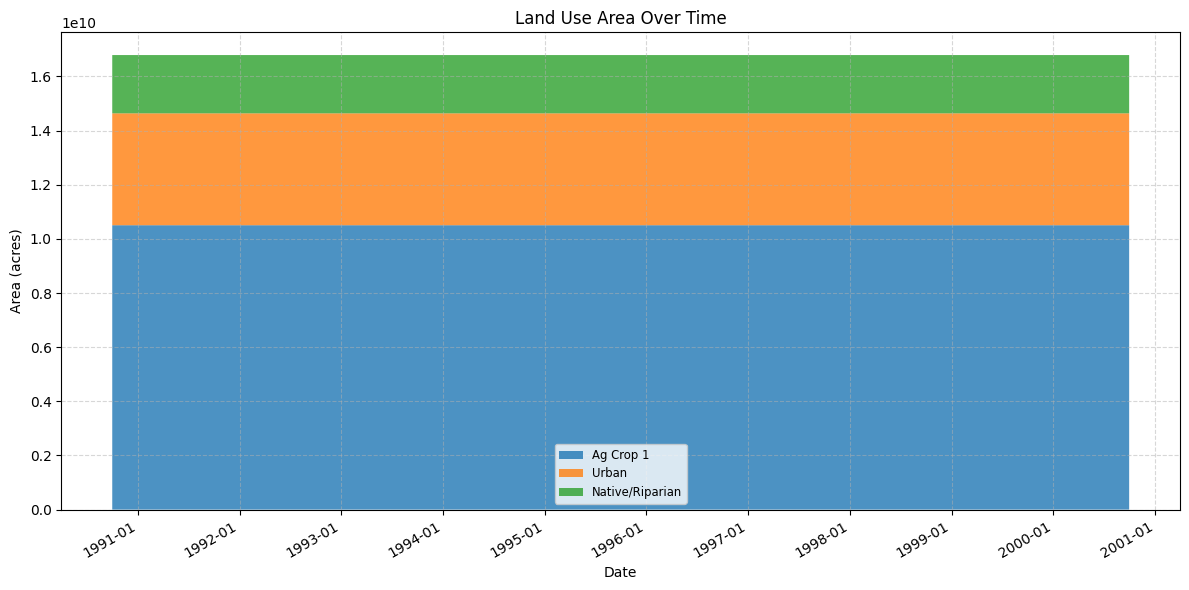

In [11]:
fig, ax = timeseries.plot_land_use_area_timeseries(model)
plt.show()

## Trends

Per-node linear trend and seasonal amplitude over the simulation.

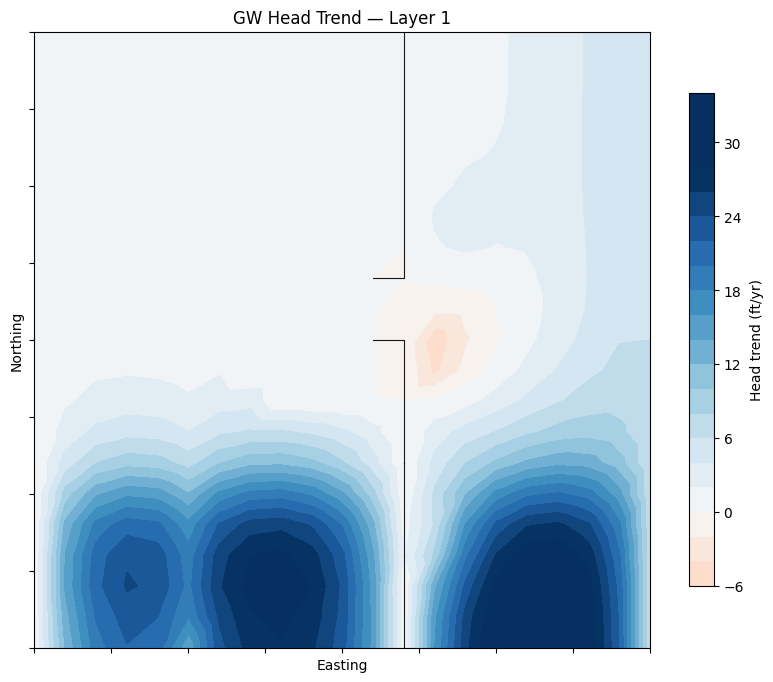

In [12]:
from iwfm_io.plots import trends

fig, ax = trends.plot_head_trend_map(model, layer=1,
                                     begin_date=BEGIN, end_date=END)
plt.show()

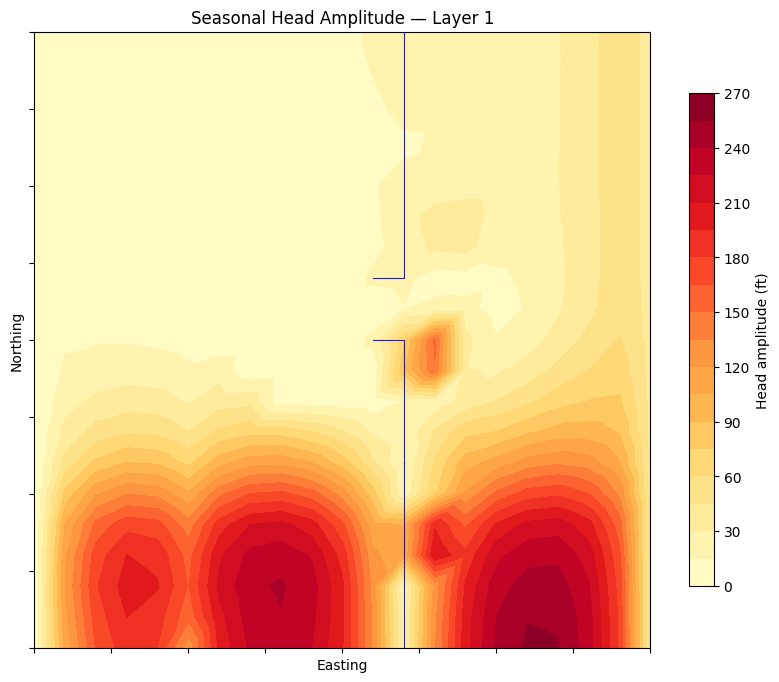

In [13]:
fig, ax = trends.plot_seasonal_amplitude_map(model, layer=1,
                                             begin_date=BEGIN, end_date=END)
plt.show()

## Seasonal patterns

These take plain `dates, values` sequences — feed them any hydrograph.

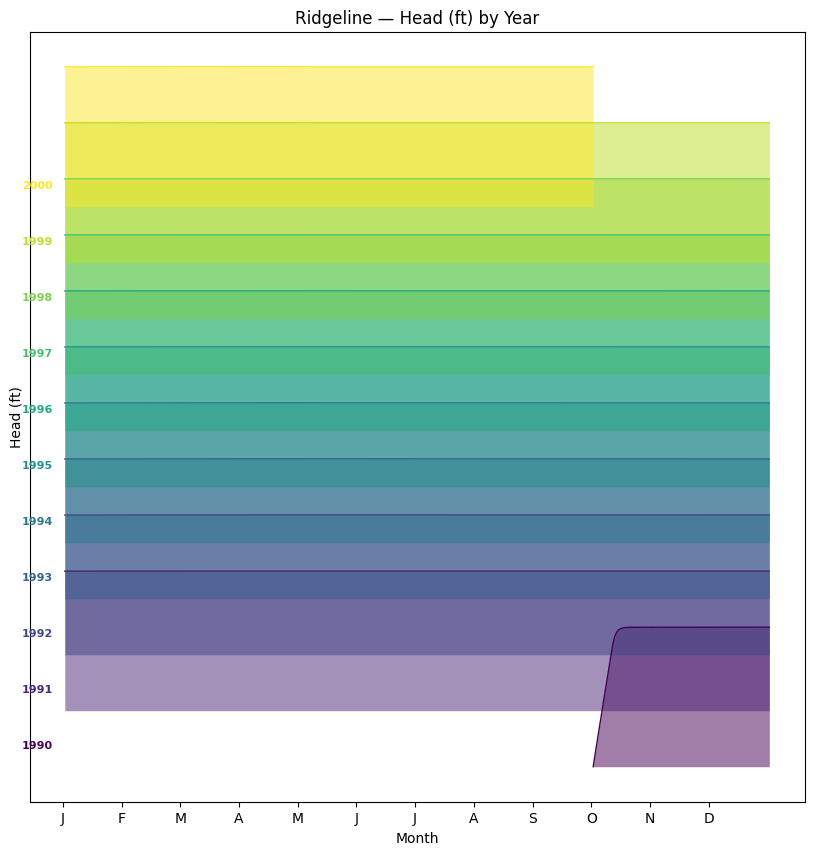

In [14]:
from iwfm_io import read_hydrograph_hdf
from iwfm_io.plots import seasonal

hyd = read_hydrograph_hdf(RESULTS_DIR / "GWHyd.hdf")
dates = list(hyd.index.to_pydatetime())
values = hyd.iloc[:, 0].values

fig, ax = seasonal.plot_ridgeline(dates, values, value_label="Head (ft)")
plt.show()

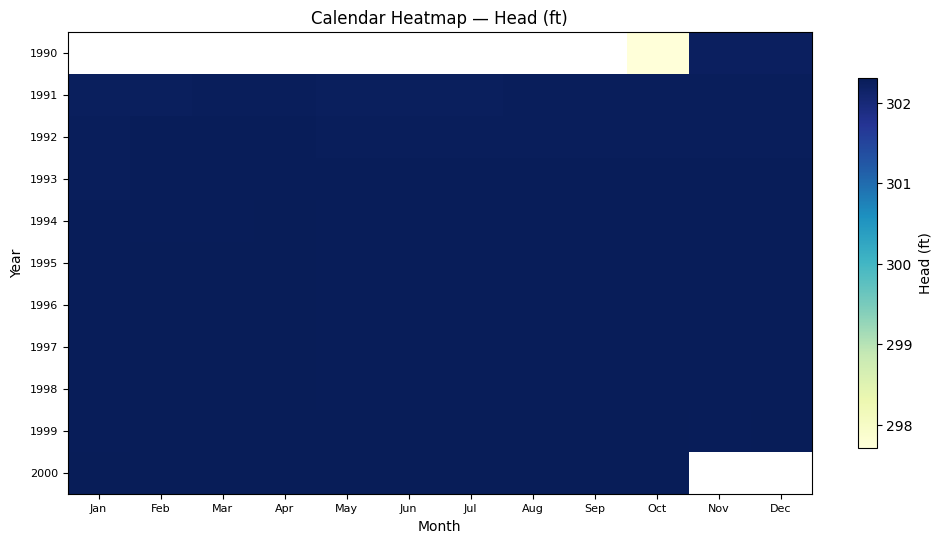

In [15]:
fig, ax = seasonal.plot_calendar_heatmap(dates, values, value_label="Head (ft)")
plt.show()

## Spatial patterns

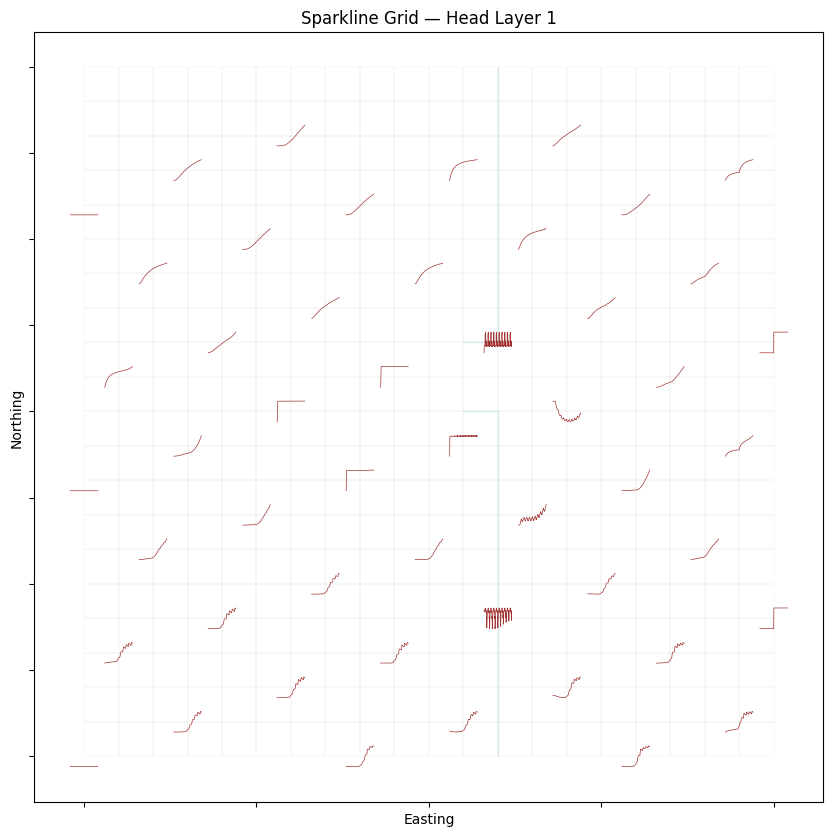

In [16]:
from iwfm_io.plots import spatial_patterns

fig, ax = spatial_patterns.plot_sparkline_grid(
    model, layer=1, begin_date=BEGIN, end_date=END)
plt.show()

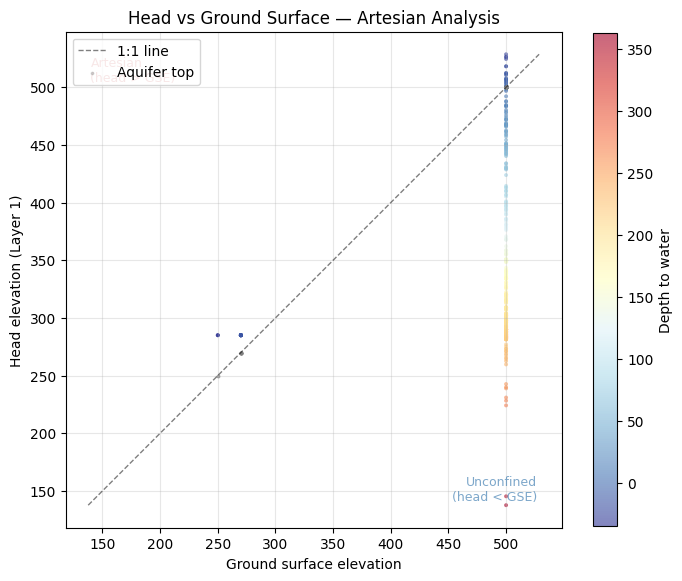

In [17]:
fig, ax = spatial_patterns.plot_head_vs_gse_scatter(model, layer=1)
plt.show()

## Summary statistics

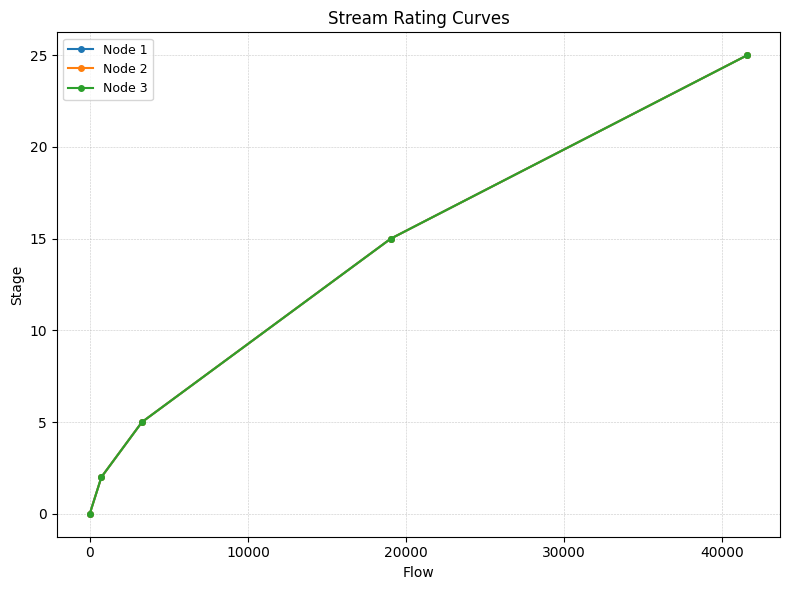

In [18]:
from iwfm_io.plots import summary

fig, ax = summary.plot_rating_curve(model, stream_nodes=[1, 2, 3])
plt.show()

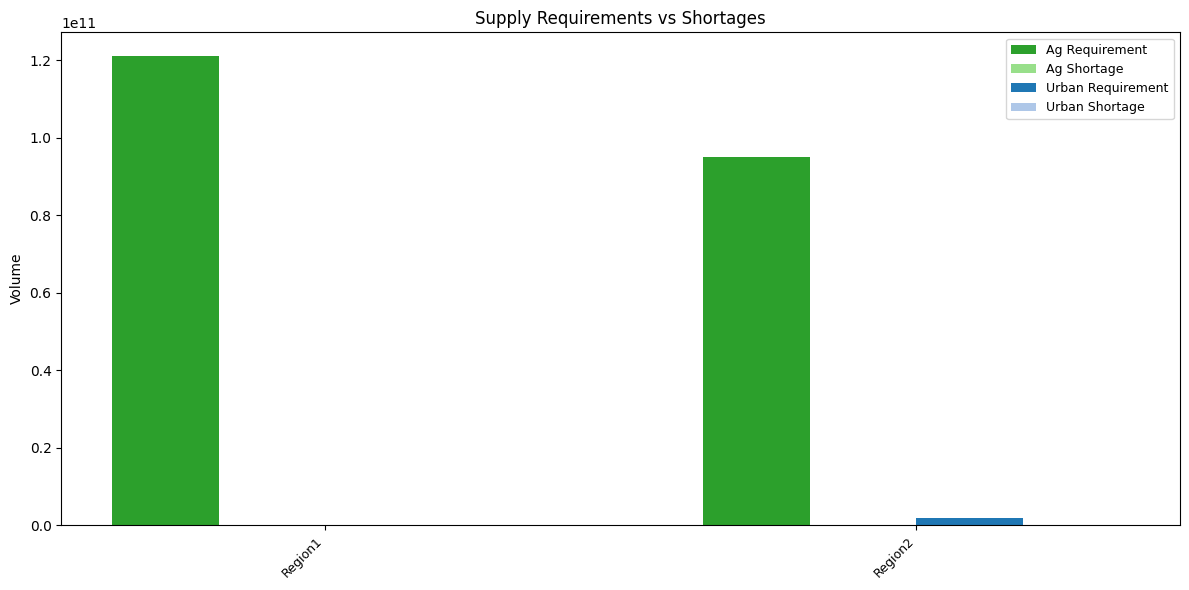

In [19]:
# Supply vs demand per subregion (adapter serves this from LWU budget files)
n_sub = len(model.subregions_df())
fig, ax = summary.plot_supply_vs_demand(
    model, 1, list(range(1, n_sub + 1)), 1, list(range(1, n_sub + 1)))
plt.show()

## Water balance

The generic Sankey/butterfly functions take `names, values` — here fed
from the GW budget HDF (the `plot_budget_*` wrappers do the same via a
DLL model).

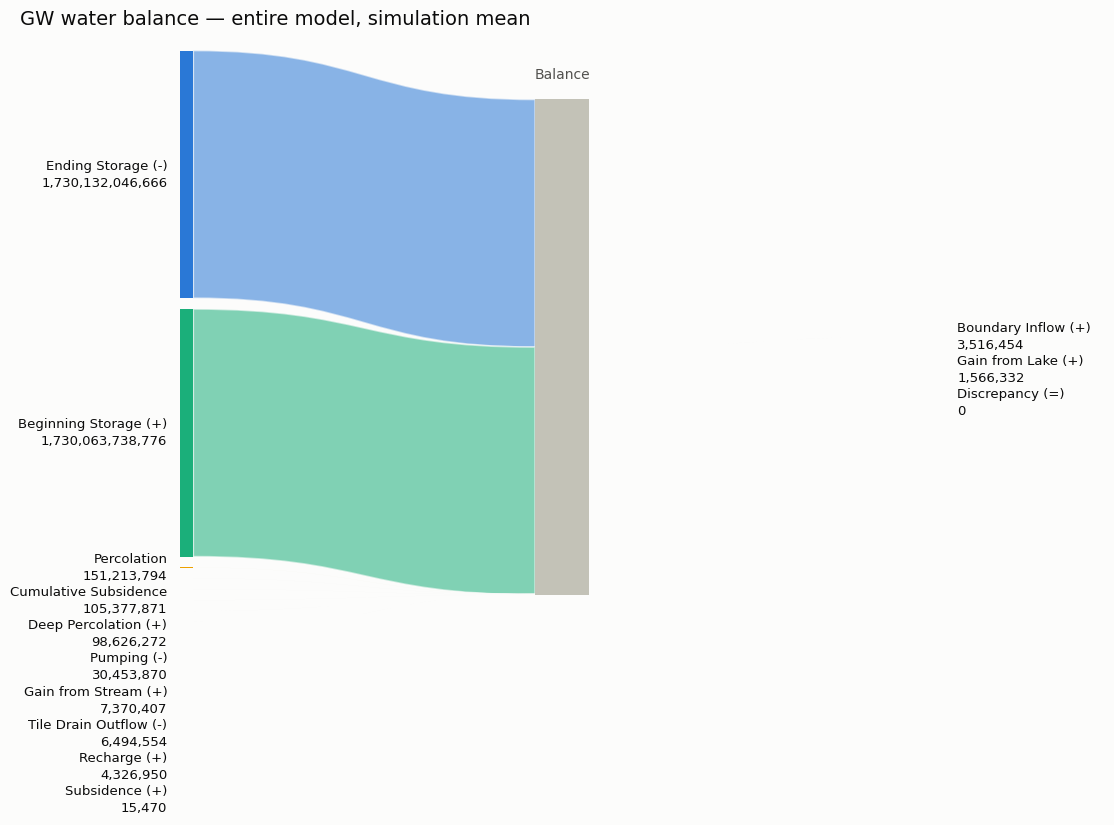

In [20]:
from iwfm_io import read_budget_hdf
from iwfm_io.plots import water_balance

bud = read_budget_hdf(RESULTS_DIR / "GW.hdf")
df = bud["data"]["ENTIRE MODEL AREA"]

fig, ax = water_balance.plot_water_balance_sankey(
    df.columns.tolist(), df.mean().values.tolist(),
    title="GW water balance — entire model, simulation mean")
plt.show()

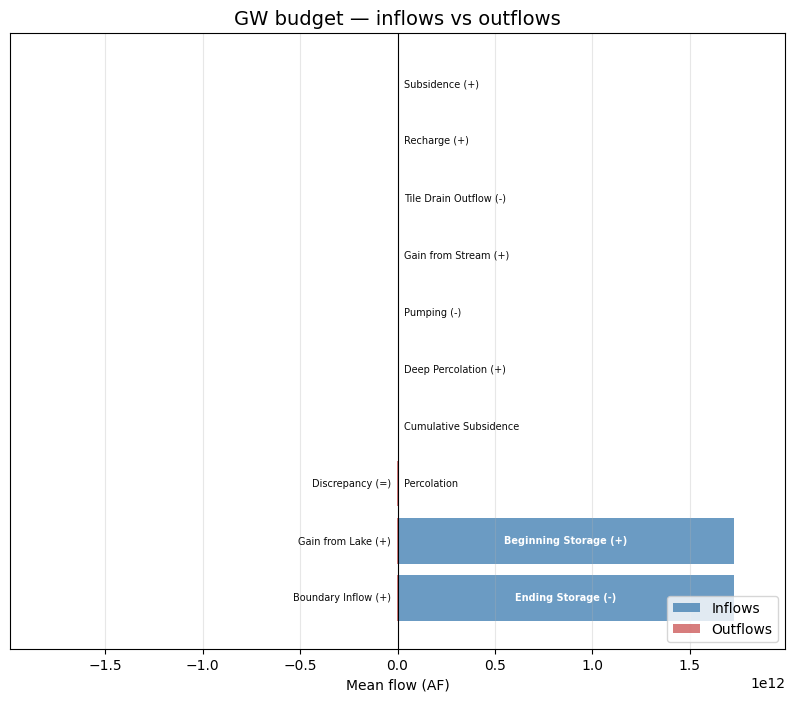

In [21]:
fig, ax = water_balance.plot_butterfly_chart(
    df.columns.tolist(), df.mean().values.tolist(),
    title="GW budget — inflows vs outflows")
plt.show()

## Stream analysis

Per-node stream–aquifer exchange, served from the stream-node budget HDF.

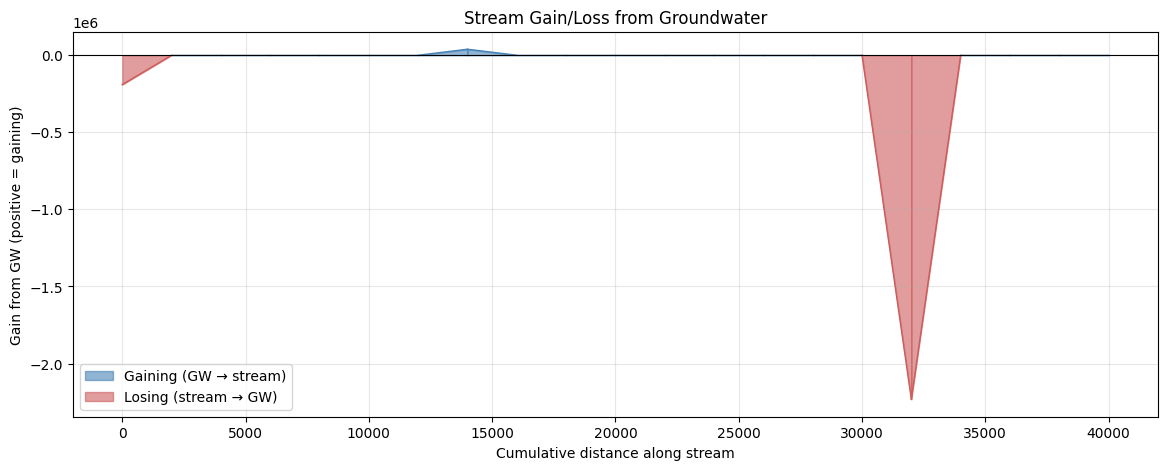

In [22]:
from iwfm_io.plots import stream_analysis

fig, ax = stream_analysis.plot_stream_gain_loss_profile(model)
plt.show()

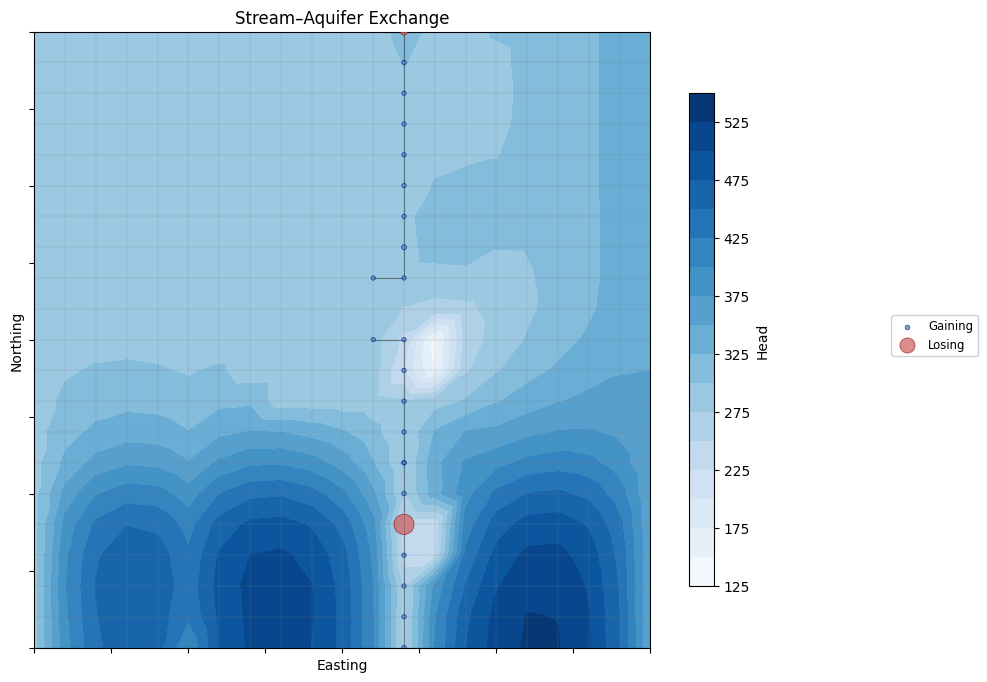

In [23]:
fig, ax = stream_analysis.plot_stream_aquifer_exchange_map(model)
plt.show()

## Subsidence

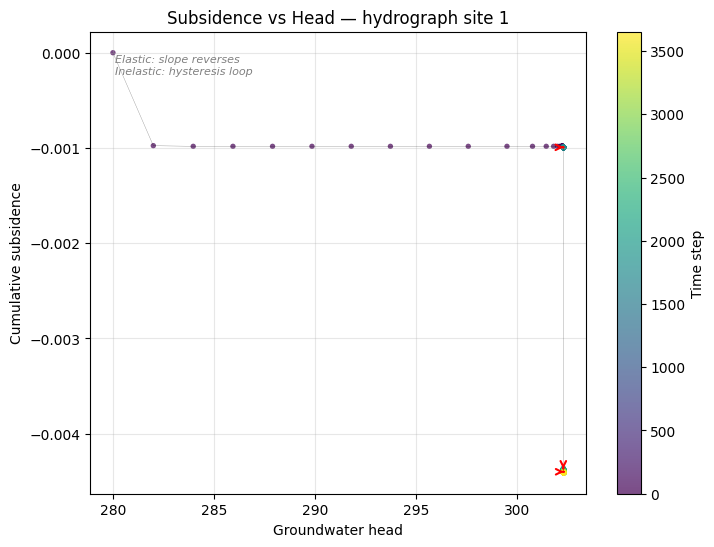

In [24]:
from iwfm_io.plots import subsidence

sub_hyd = read_hydrograph_hdf(RESULTS_DIR / "Subsidence.hdf")
fig, ax = subsidence.plot_subsidence_vs_head(
    hyd.iloc[:, 0], sub_hyd.iloc[:, 0], dates=list(sub_hyd.index),
    node_label="hydrograph site 1")
plt.show()

## Supply & demand

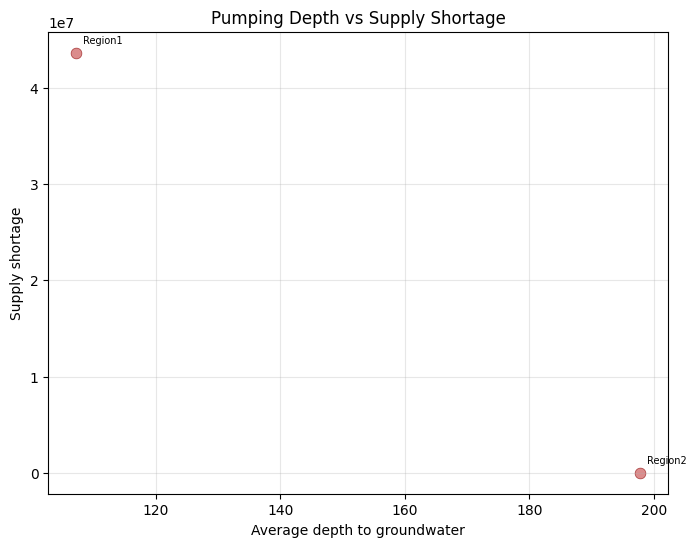

In [25]:
from iwfm_io.plots import supply_demand

fig, ax = supply_demand.plot_subregion_depth_vs_shortage(model, 1)
plt.show()

## Connectivity

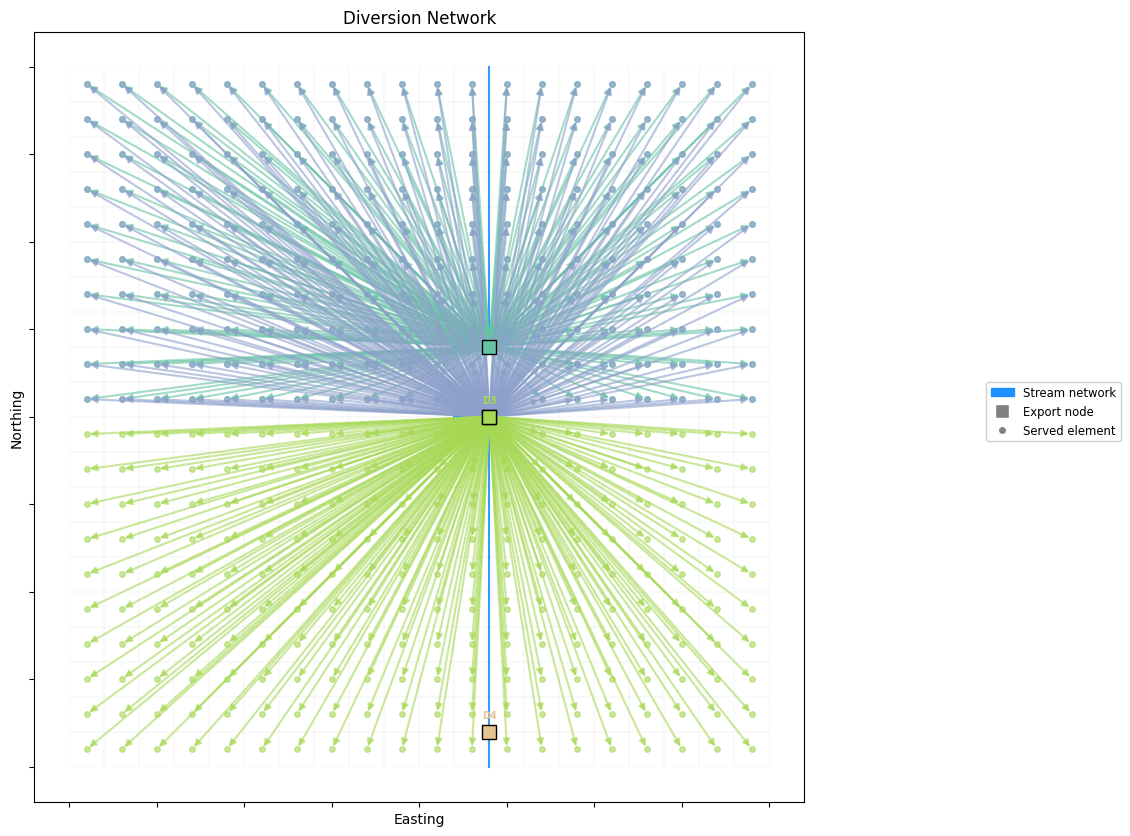

In [26]:
from iwfm_io.plots import connectivity

fig, ax = connectivity.plot_diversion_network(model)
plt.show()

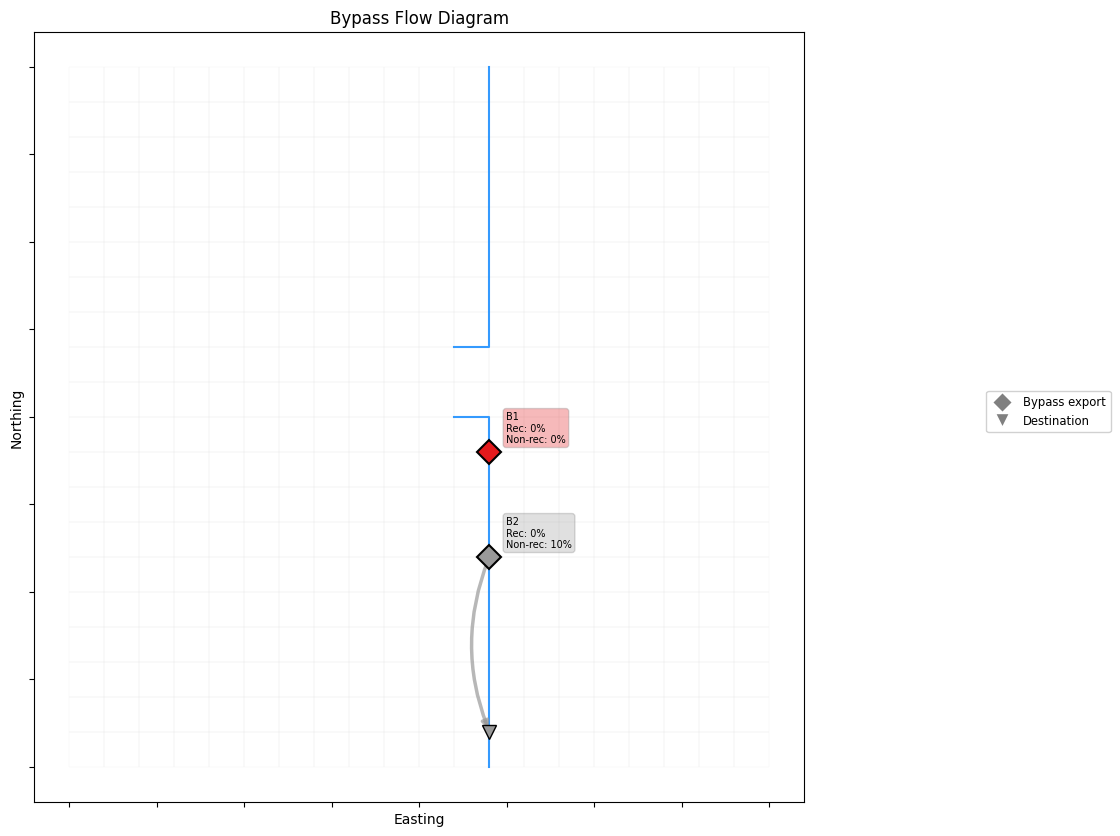

In [27]:
fig, ax = connectivity.plot_bypass_flow_diagram(model)
plt.show()

## Animations

Three animation functions render head/DTW/stream-flow evolution to GIF
or MP4. They work exactly like the static maps (not executed here to
keep the notebook light):

```python
from iwfm_io.plots import animations
animations.animate_gw_heads(model, layer=1,
                            begin_date=BEGIN, end_date="09/30/1992_24:00",
                            save_path="gw_heads.gif")
animations.animate_depth_to_water(model, layer=1,
                                  begin_date=BEGIN, end_date=END,
                                  save_path="dtw.gif")
```

## Build your own maps: the shared primitives

Everything above is assembled from reusable pieces in
`iwfm_io.plots` — use them directly for custom figures.

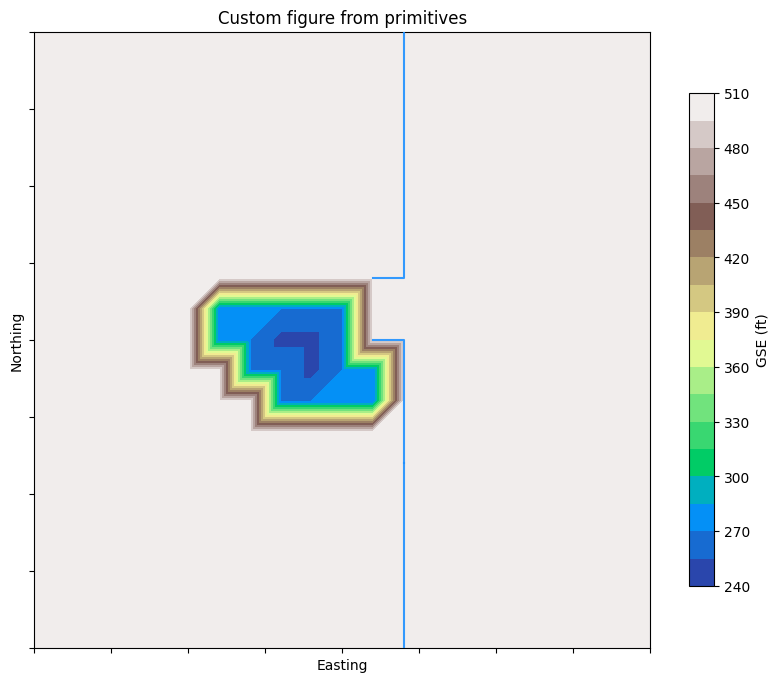

In [28]:
import numpy as np

from iwfm_io.plots import overlay_streams, plot_contour_map, plot_element_map

# node values -> filled contours + stream overlay
strat = model.stratigraphy_df()
fig, ax, cs, cb = plot_contour_map(
    model, strat["elevation"].values, cmap="terrain",
    label="GSE (ft)", title="Custom figure from primitives")
overlay_streams(model, ax)
plt.show()

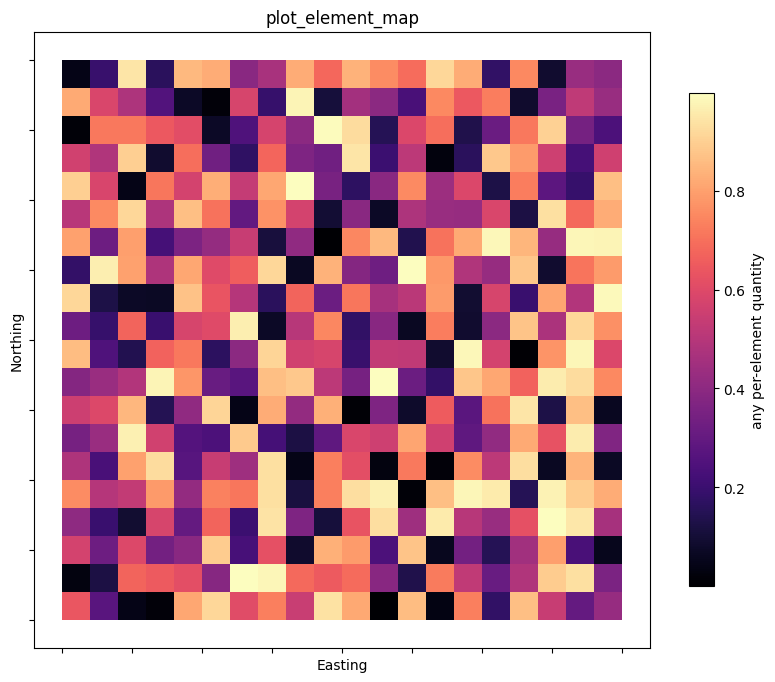

In [29]:
# element values -> colored polygons
elems = model.elements_df()
rng = np.random.default_rng(0)
fig, ax, *_ = plot_element_map(
    model, rng.uniform(size=len(elems)), cmap="magma",
    label="any per-element quantity", title="plot_element_map")
plt.show()

## The full set

| Module | Functions |
|--------|-----------|
| `maps` | 11 — grid, GSE, contours, DTW, parameters, wells, lakes, drains |
| `profiles` | 2 — cross-section, longitudinal profile |
| `timeseries` | 7 — heads, stream flow/stage, budgets, land use, storage |
| `trends` | 4 — trend map, amplitude, drawdown rate, recovery lag |
| `seasonal` | 4 — ridgeline, calendar heatmap, polar |
| `spatial_patterns` | 3 — sparkline grid, small multiples, GSE scatter |
| `summary` | 7 — pies, monthly/annual bars, rating curves, histograms |
| `water_balance` | 5 — Sankey, butterfly, cumulative departure |
| `stream_analysis` | 2 — gain/loss profile, exchange map |
| `animations` | 3 — heads, DTW, stream flows |
| `subsidence` | 2 — bowl map, subsidence vs head |
| `supply_demand` | 4 — supply gap, depth vs shortage |
| `connectivity` | 2 — diversion network, bypass diagram |

Calibration figures (`iwfm_io.plots.calibration`) appear in notebook 10.
A full rendered gallery for the real C2VSimFG model is in
[`docs/GALLERY.md`](https://github.com/SercanC/iwfm-io/blob/main/docs/GALLERY.md).